# Investigating Revenue Decline: A Malay Hawker Stall Owner's Data-Driven Approach

## The Business Problem

I run a Malay food stall at an HDB hawker centre in Singapore — serving nasi padang, mee rebus, and mee soto. Over the past year, my daily takings have been slipping. Ingredient costs keep climbing, rental fees are up, and the lunchtime crowd feels thinner than it used to be. My first instinct is to raise menu prices — but I've seen neighbouring stalls lose regulars over even a 50-cent increase.

Before I make any hasty decisions, I want to look at the numbers. I obtained a dataset covering 220 Malay hawker stalls across Singapore — different locations, different price points, different operating conditions. My plan: use statistical analysis to understand what truly drives revenue for Malay stalls, and figure out a smarter pricing strategy.

## The Dataset

`Hawker Data Statistics.csv` — 220 Malay stall observations with the following variables:

| Variable | Type | Description |
|----------|------|-------------|
| `daily_revenue` | numeric | Daily revenue in SGD |
| `avg_price` | numeric | Average dish price in SGD |
| `location_type` | categorical | CBD, HDB, or Tourist area |
| `competition` | integer | Number of nearby competing stalls |
| `day_type` | categorical | Weekday or Weekend |
| `stall_age` | numeric | Years the stall has been operating |
| `has_social_media` | categorical | Whether the stall uses social media (Yes/No) |
| `social_media_spend` | numeric | Monthly social media marketing spend in SGD |

## My Investigation Plan

Each finding will guide the next question:

1. **Where do I stand?** — How does my stall compare to other Malay stalls, and does location matter more than I think?
2. **Is the location effect real?** — Can I prove statistically that HDB stalls earn less, or is it just noise?
3. **What truly drives revenue?** — After controlling for all factors, what matters most?
4. **Can I raise prices AND grow revenue?** — Simulate a combined strategy of modest price increase + social media investment.

In [457]:
library(e1071)
# Notebook figures: 16:9 landscape (IRkernel)
options(repr.plot.width = 12, repr.plot.height = 12 * 9 / 16, repr.plot.res = 120)
par(bg = "white")

hawker_data <- read.csv("Hawker Data Statistics.csv")
str(hawker_data)
head(hawker_data)


'data.frame':	220 obs. of  8 variables:
 $ daily_revenue     : num  82.6 130.7 150.7 79 76 ...
 $ avg_price         : num  3.57 2.76 4.88 5.2 4.87 6.58 4.48 5.55 3.33 2.96 ...
 $ location_type     : chr  "HDB" "HDB" "HDB" "HDB" ...
 $ competition       : int  9 12 4 2 10 5 8 7 5 12 ...
 $ day_type          : chr  "Weekday" "Weekday" "Weekend" "Weekday" ...
 $ stall_age         : num  21.4 26.8 1.2 27.4 1.8 28.2 15.2 5.6 8.3 26.1 ...
 $ has_social_media  : chr  "No" "Yes" "Yes" "No" ...
 $ social_media_spend: num  0 119 234 0 0 155 105 0 100 0 ...


,daily_revenue,avg_price,location_type,competition,day_type,stall_age,has_social_media,social_media_spend
,<dbl>,<dbl>,<chr>,<int>,<chr>,<dbl>,<chr>,<dbl>
1,82.60,3.57,HDB,9,Weekday,21.4,No,0
2,130.69,2.76,HDB,12,Weekday,26.8,Yes,119
3,150.70,4.88,HDB,4,Weekend,1.2,Yes,234
4,79.02,5.20,HDB,2,Weekday,27.4,No,0
5,76.01,4.87,HDB,10,Weekend,1.8,No,0
6,188.61,6.58,CBD,5,Weekend,28.2,Yes,155


# Discovery 1: Where Do I Stand?

My sales have been dropping, and I need to understand the bigger picture. I start with **my own** sales: I estimate my typical daily revenue from a month's worth of records. Then I benchmark that figure against the overall Malay stall population using a **95% confidence interval for the population mean** $\mu$. After that, I break revenue down by location — because a stall in the CBD and a stall in an HDB estate are operating in very different markets.

## Step 1: Finding My Mean

I have **30 consecutive days** of my own daily revenue (simulated here as draws from a process centred around what I have been seeing lately). The **sample mean** $\bar{X}_{\text{my}}$ is my best estimate of my typical day, with the sample standard deviation summarising day-to-day volatility.

*Concepts: Random variables (Week 3), Sample mean and spread (Week 6)*


=== Step 1: My Stall's Mean Revenue (30 Days) ===

Daily revenues (SGD):
 [1] 135.42  96.71 115.26 120.66 116.09 105.88 138.23 106.11 148.37 106.75
[11] 134.10 153.73  80.22 102.42 105.33 120.72 102.31  54.87  59.19 134.40
[21] 101.87  72.37 104.56 132.29 145.90  99.39 102.85  72.74 117.20  95.20

My stall sample mean (x-bar_my): $ 109.37 
My stall sample SD:              $ 25.1 
Number of days (n):               30 


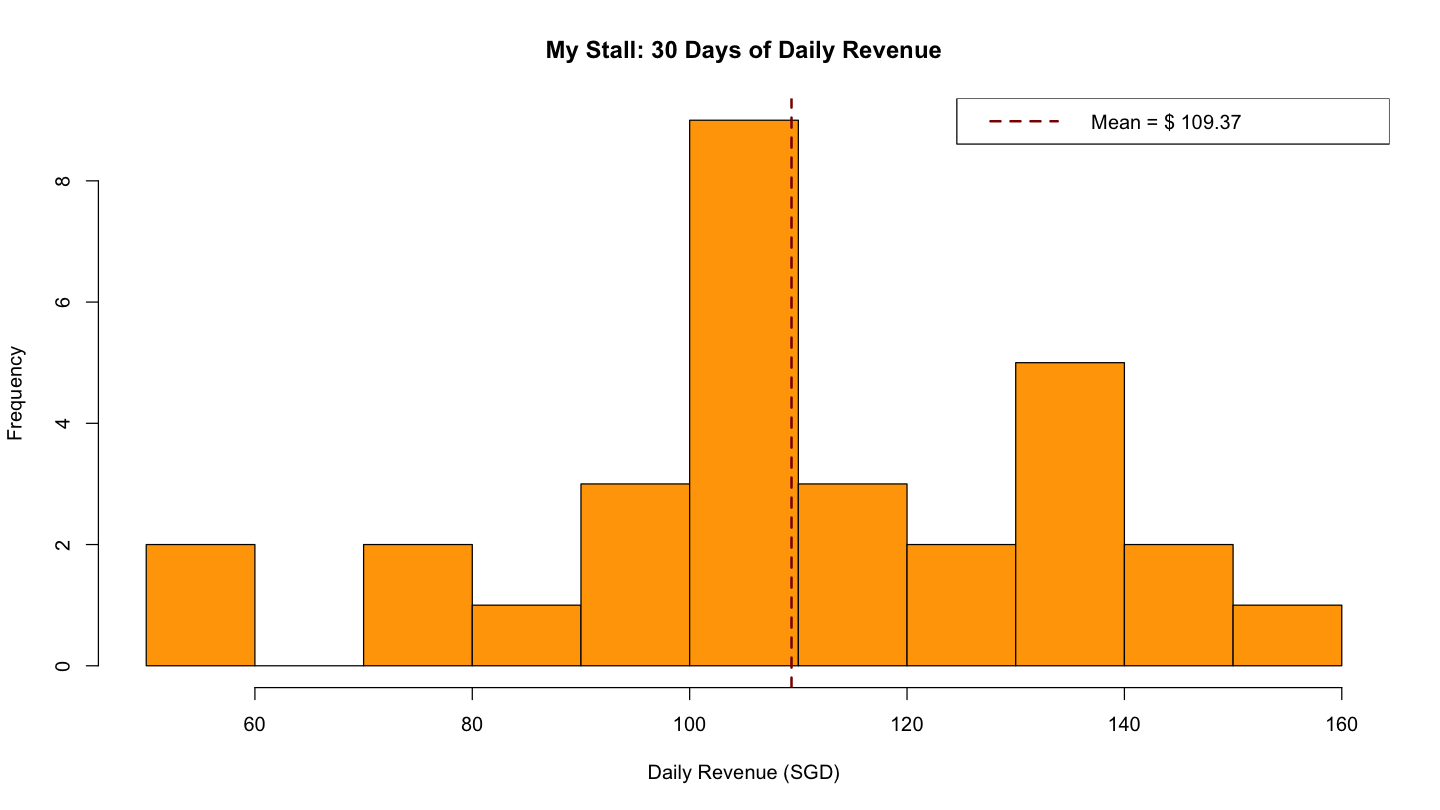

In [458]:
set.seed(42)
my_revenue <- round(rnorm(30, mean = 108, sd = 20), 2)

cat("=== Step 1: My Stall's Mean Revenue (30 Days) ===\n\n")
cat("Daily revenues (SGD):\n")
print(my_revenue)

n_my <- length(my_revenue)
xbar_my <- mean(my_revenue)
s_my <- sd(my_revenue)

cat("\nMy stall sample mean (x-bar_my): $", round(xbar_my, 2), "\n")
cat("My stall sample SD:              $", round(s_my, 2), "\n")
cat("Number of days (n):              ", n_my, "\n")

options(repr.plot.width = 12, repr.plot.height = 12 * 9 / 16, repr.plot.res = 120)

par(bg = "white")
hist(my_revenue,
     breaks = 12,
     col = "orange",
     main = "My Stall: 30 Days of Daily Revenue",
     xlab = "Daily Revenue (SGD)",
     ylab = "Frequency")
abline(v = xbar_my, col = "darkred", lwd = 2, lty = 2)
legend("topright",
       legend = paste("Mean = $", round(xbar_my, 2)),
       col = "darkred", lty = 2, lwd = 2)


## Step 2: Comparing My Stall to the Overall Population Mean (95% CI for $\mu$)

Having computed $\bar{X}_{\text{my}}$ in Step 1, I turn to the **220-stall** dataset. I treat those daily revenues as a random sample and ask: where does the **true population mean** $\mu$ plausibly lie? I construct a **95% confidence interval** for $\mu$. If my mean falls **below** the lower bound of that interval, my typical day looks worse than the benchmark implied by the sample — I will describe that as **underperforming** relative to the overall Malay stall population.

By the **Central Limit Theorem** (Week 6), the sampling distribution of $\bar{X}$ is approximately normal for large $n$. Since $\sigma$ is unknown, I use the **t-distribution** with $n - 1$ degrees of freedom:

$$\text{95\% CI:} \quad \bar{X} \pm t_{0.975,\, n-1} \cdot \frac{S}{\sqrt{n}}$$

*Concepts: CLT (Week 6), t-based confidence interval with unknown $\sigma$ (Week 7)*


=== Step 2: 95% Confidence Interval for Overall Malay Stall Mean ===

Overall sample size:   n = 220 
Overall sample mean:   $ 134.76 
Overall sample SD:     $ 56.2 
Standard error:        $ 3.79 
t-critical (0.975, df = 219 ): 1.9709 
95% CI for mu:         [$ 127.29 , $ 142.22 ]

=== Comparison: My Mean vs 95% CI for mu ===

My stall mean (from Step 1): $ 109.37 
95% CI lower bound:          $ 127.29 

My stall mean ($ 109.37 ) is BELOW the 95% CI lower bound ($ 127.29 ).
==> YES, my stall is UNDERPERFORMING.
    My revenue is significantly lower than what we'd expect from the average Malay stall.


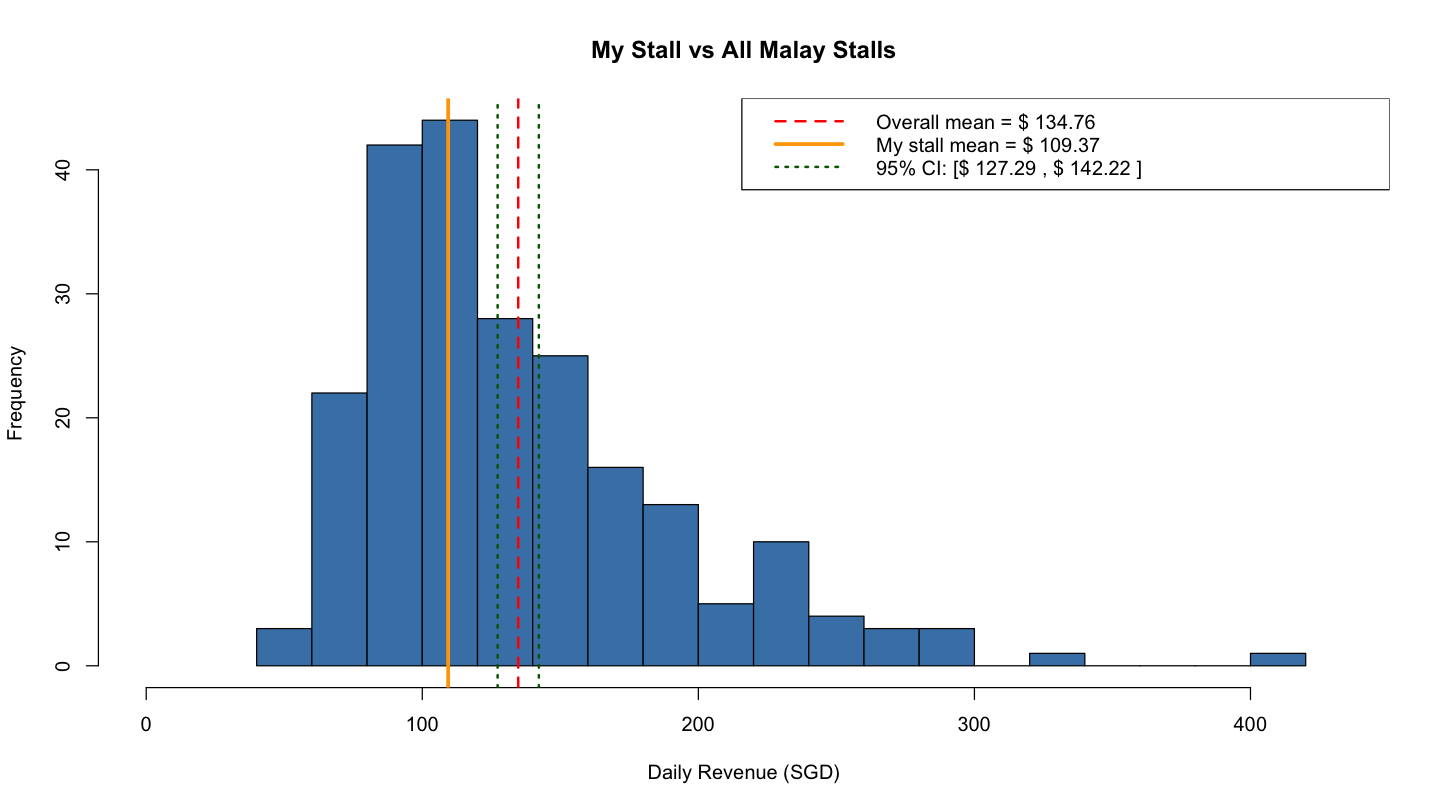

In [459]:
cat("=== Step 2: 95% Confidence Interval for Overall Malay Stall Mean ===\n\n")

n_all <- nrow(hawker_data)
xbar_all <- mean(hawker_data$daily_revenue)
s_all <- sd(hawker_data$daily_revenue)
se_all <- s_all / sqrt(n_all)
t_crit <- qt(0.975, df = n_all - 1)
ci_lower <- xbar_all - t_crit * se_all
ci_upper <- xbar_all + t_crit * se_all

cat("Overall sample size:   n =", n_all, "\n")
cat("Overall sample mean:   $", round(xbar_all, 2), "\n")
cat("Overall sample SD:     $", round(s_all, 2), "\n")
cat("Standard error:        $", round(se_all, 2), "\n")
cat("t-critical (0.975, df =", n_all - 1, "):", round(t_crit, 4), "\n")
cat("95% CI for mu:         [$", round(ci_lower, 2), ", $", round(ci_upper, 2), "]\n")

cat("\n=== Comparison: My Mean vs 95% CI for mu ===\n\n")
cat("My stall mean (from Step 1): $", round(xbar_my, 2), "\n")
cat("95% CI lower bound:          $", round(ci_lower, 2), "\n\n")

if (xbar_my < ci_lower) {
  cat("My stall mean ($", round(xbar_my, 2), ") is BELOW the 95% CI lower bound ($", round(ci_lower, 2), ").\n")
  cat("==> YES, my stall is UNDERPERFORMING.\n")
  cat("    My revenue is significantly lower than what we'd expect from the average Malay stall.\n")
} else {
  cat("My stall mean falls within (or above) the 95% CI.\n")
  cat("==> No clear evidence of underperformance.\n")
}

options(repr.plot.width = 12, repr.plot.height = 12 * 9 / 16, repr.plot.res = 120)

par(bg = "white")
hist(hawker_data$daily_revenue,
     breaks = 20,
     col = "steelblue",
     main = "My Stall vs All Malay Stalls",
     xlab = "Daily Revenue (SGD)",
     ylab = "Frequency",
     xlim = c(0, max(hawker_data$daily_revenue) + 20))
abline(v = ci_lower, col = "darkgreen", lwd = 2, lty = 3)
abline(v = ci_upper, col = "darkgreen", lwd = 2, lty = 3)
abline(v = xbar_all, col = "red", lwd = 2, lty = 2)
abline(v = xbar_my, col = "orange", lwd = 3, lty = 1)
legend("topright",
       legend = c(paste("Overall mean = $", round(xbar_all, 2)),
                  paste("My stall mean = $", round(xbar_my, 2)),
                  paste("95% CI: [$", round(ci_lower, 2), ", $", round(ci_upper, 2), "]")),
       col = c("red", "orange", "darkgreen"),
       lty = c(2, 1, 3),
       lwd = c(2, 3, 2))


### Interpretation

The 95% confidence interval tells us that the true average daily revenue for Malay stalls plausibly lies somewhere between the green dashed lines. My stall's mean (orange line) falls **below the lower bound** of this range — it doesn't even make it into the interval.

This means my revenue is not just a little below average — it's **significantly lower** than what we'd expect from the typical Malay stall.

**My stall is underperforming.** But *why*? Is it simply because I'm at an HDB hawker centre, or is something else going on? Next, I break revenue down by **location type** (Step 3) to see where I sit relative to CBD, HDB, and Tourist markets.

## Step 3: Compare by Area

The dataset includes stalls in CBD, HDB, and Tourist areas — very different operating environments. Since I operate at an HDB hawker centre, I need to see where I sit relative to stalls in other locations.

*Concepts: Descriptive statistics and boxplots (Week 6)*

=== Revenue by Location Type ===

  HDB      n=120  mean=$106.60  median=$102.60  sd=$32.44
  CBD      n=55   mean=$192.00  median=$185.42  sd=$58.83
  Tourist  n=45   mean=$139.86  median=$134.06  sd=$48.39


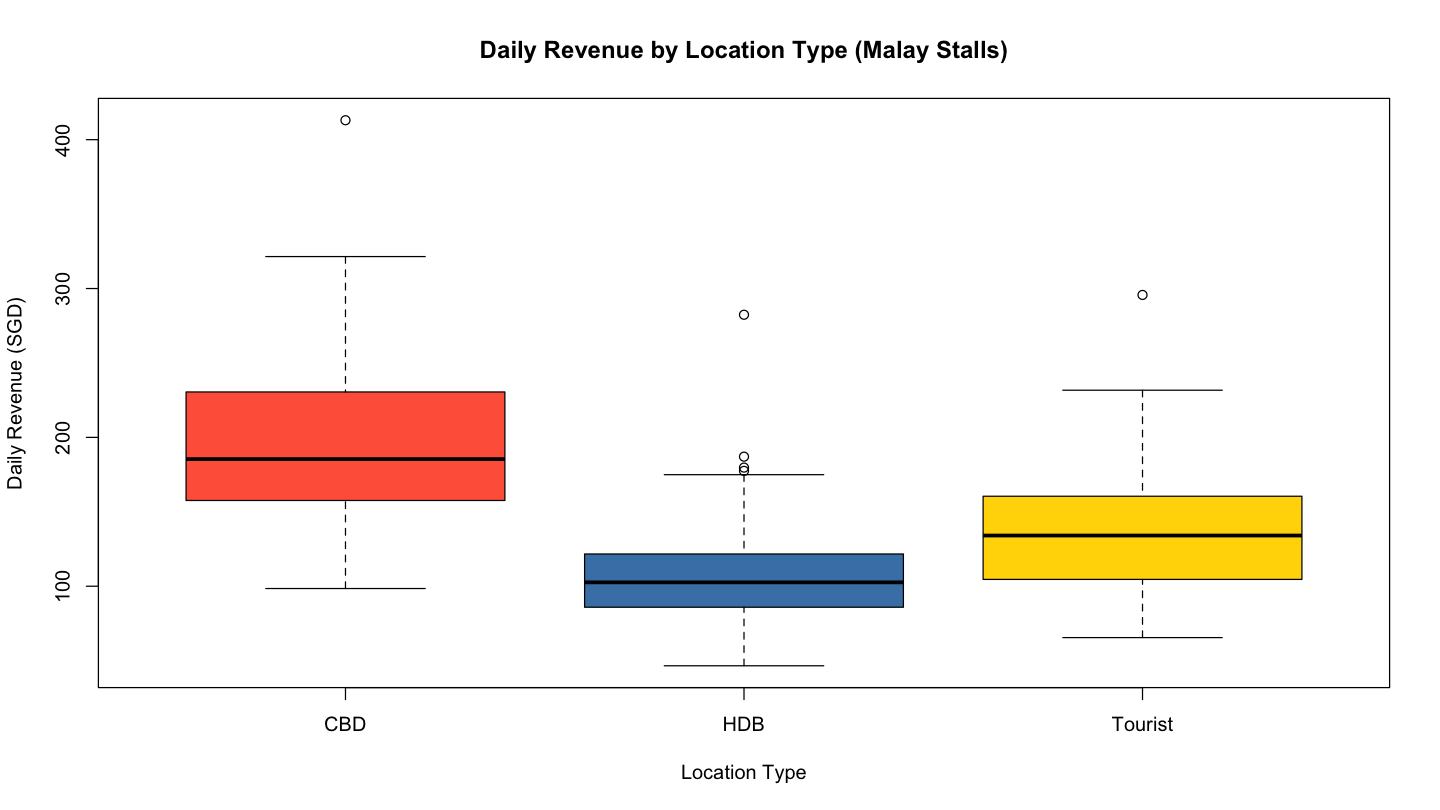

In [460]:
cat("=== Revenue by Location Type ===\n\n")
for (loc in c("HDB", "CBD", "Tourist")) {
  d <- hawker_data[hawker_data$location_type == loc, ]
  cat(sprintf("  %-8s n=%-3d  mean=$%.2f  median=$%.2f  sd=$%.2f\n",
              loc, nrow(d), mean(d$daily_revenue),
              median(d$daily_revenue), sd(d$daily_revenue)))
}

par(bg = "white")
boxplot(daily_revenue ~ location_type,
        data = hawker_data,
        col = c("tomato", "steelblue", "gold"),
        main = "Daily Revenue by Location Type (Malay Stalls)",
        xlab = "Location Type",
        ylab = "Daily Revenue (SGD)")


## Step 4: The Price-Revenue Paradox

HDB Malay stalls earn the least — that's clear from the Step 3 boxplot. My instinct says: maybe I should charge more. Let me check: across all 220 Malay stalls, what is the relationship between average plate price and daily revenue?

I'll compute the **covariance** $\text{Cov}(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$ and the **Pearson correlation coefficient** $\rho = \frac{\text{Cov}(X,Y)}{\text{SD}(X) \cdot \text{SD}(Y)}$, which standardises the covariance to a [-1, 1] scale.

*Concepts: Covariance and correlation coefficient (Week 5)*

=== Overall Price-Revenue Relationship ===

Cov(price, revenue) = 28.455 
Cor(price, revenue) = 0.3594 

The correlation is POSITIVE -- stalls that charge more tend to earn more.
Does this mean raising prices will help?


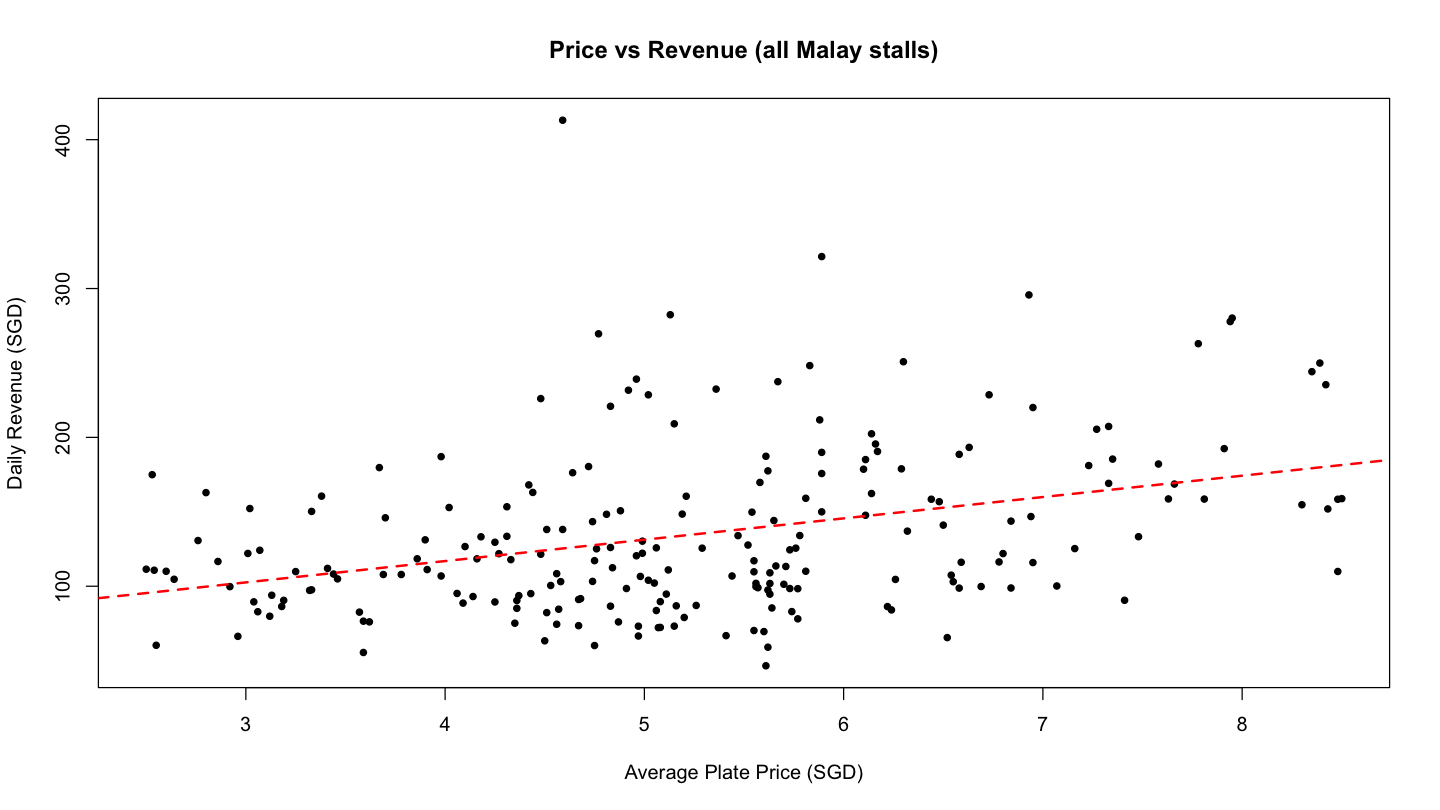

In [461]:
cov_overall <- cov(hawker_data$avg_price, hawker_data$daily_revenue)
cor_overall <- cor(hawker_data$avg_price, hawker_data$daily_revenue)

cat("=== Overall Price-Revenue Relationship ===\n\n")
cat("Cov(price, revenue) =", round(cov_overall, 4), "\n")
cat("Cor(price, revenue) =", round(cor_overall, 4), "\n\n")
cat("The correlation is POSITIVE -- stalls that charge more tend to earn more.\n")
cat("Does this mean raising prices will help?\n")

options(repr.plot.width = 12, repr.plot.height = 12 * 9 / 16, repr.plot.res = 120)

par(bg = "white")
plot(hawker_data$avg_price, hawker_data$daily_revenue,
     col = "black",
     pch = 19,
     cex = 0.7,
     main = "Price vs Revenue (all Malay stalls)",
     xlab = "Average Plate Price (SGD)",
     ylab = "Daily Revenue (SGD)")
abline(lm(daily_revenue ~ avg_price, data = hawker_data),
       col = "red", lwd = 2, lty = 2)

The overall picture looks encouraging — a positive correlation suggests higher prices go hand in hand with higher revenue. But wait. What if I break this down by location? Let me compute the **conditional** correlation: $\text{Cor}(\text{price}, \text{revenue} \mid \text{location} = \ell)$ for each location type $\ell$.

This is where **conditional probability** (Week 2) becomes critical: the probability structure can look completely different once we condition on a relevant variable.

*Concepts: Conditional probability (Week 2), Correlation conditioned on a variable (Week 5)*

=== Correlation: Price vs Revenue BY Location ===

  Cor(price, revenue | location = HDB    ) = -0.1062   Cov = -3.3333  (n=120)
  Cor(price, revenue | location = CBD    ) = -0.2367   Cov = -15.4367  (n=55)
  Cor(price, revenue | location = Tourist) = -0.1176   Cov = -5.3767  (n=45)

The conditional correlations are all NEGATIVE!
Within each area, charging more is associated with LOWER revenue.


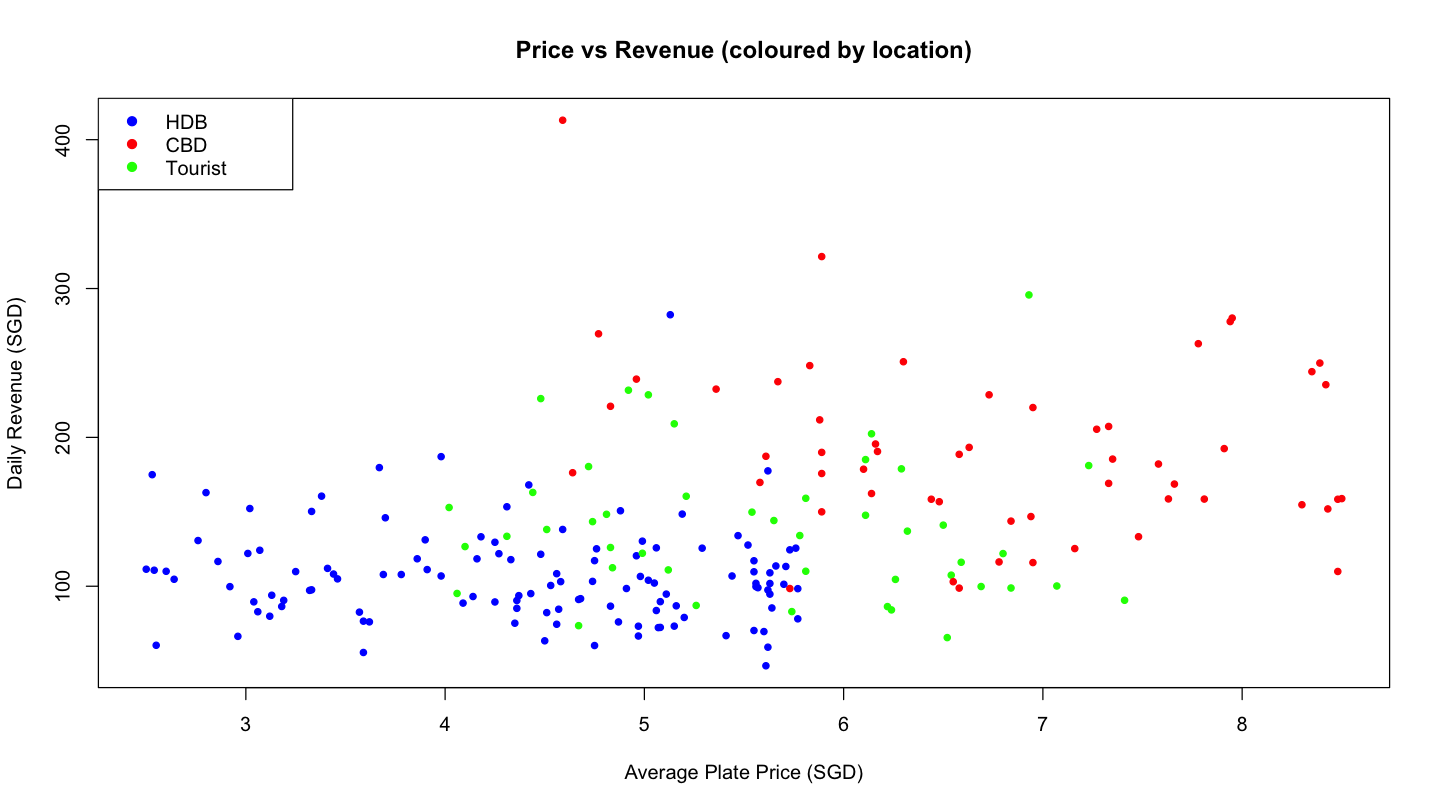

In [462]:
cat("=== Correlation: Price vs Revenue BY Location ===\n\n")
for (loc in c("HDB", "CBD", "Tourist")) {
  d <- hawker_data[hawker_data$location_type == loc, ]
  cov_loc <- cov(d$avg_price, d$daily_revenue)
  cor_loc <- cor(d$avg_price, d$daily_revenue)
  cat(sprintf("  Cor(price, revenue | location = %-7s) = %+.4f   Cov = %+.4f  (n=%d)\n",
              loc, cor_loc, cov_loc, nrow(d)))
}

cat("\nThe conditional correlations are all NEGATIVE!\n")
cat("Within each area, charging more is associated with LOWER revenue.\n")

options(repr.plot.width = 12, repr.plot.height = 12 * 9 / 16, repr.plot.res = 120)

par(bg = "white")
colors <- ifelse(hawker_data$location_type == "HDB", "blue",
          ifelse(hawker_data$location_type == "CBD", "red", "green"))

plot(hawker_data$avg_price, hawker_data$daily_revenue,
     col = colors,
     pch = 19,
     cex = 0.7,
     main = "Price vs Revenue (coloured by location)",
     xlab = "Average Plate Price (SGD)",
     ylab = "Daily Revenue (SGD)")
legend("topleft",
       legend = c("HDB", "CBD", "Tourist"),
       col = c("blue", "red", "green"),
       pch = 19)

## Simpson's Paradox

This is a textbook example of **Simpson's Paradox**: a trend that appears in aggregated data reverses when the data is split into meaningful groups.

**Why it happens:** CBD and Tourist-area stalls charge higher prices (higher rent, wealthier customers) AND earn more revenue (more foot traffic, higher spending power). So when we look at all stalls together, it *appears* that higher prices lead to higher revenue. But this is a **confounding** effect of location — location drives both price levels and revenue simultaneously.

Once we **condition** on location (i.e. compare stalls within the same area), we see the true relationship: within each area, stalls that charge more tend to earn less.

This tells me something crucial: **I cannot simply raise prices and expect revenue to follow.** The positive overall correlation was an illusion created by location confounding.

But before I act on this, I need to verify: is the revenue gap between locations **statistically significant**, or could it just be random variation in my sample?

# Discovery 2: Is the Location Effect Real?

The boxplot and descriptive stats suggest HDB Malay stalls earn less than CBD and Tourist stalls. But a chart alone isn't proof — I need to know whether this difference is **statistically significant** or could arise by chance in a sample of 220 stalls.

I'll use three approaches:
1. **Confidence intervals** to estimate the true mean revenue at each location
2. **Hypothesis testing** to formally test whether HDB stalls earn below average
3. **Regression** to quantify exactly how much each location type contributes

*Concepts: Confidence intervals (Week 7), Hypothesis testing (Weeks 8-9), Linear regression with dummy variables (Week 10)*

## Step 1: Confidence Intervals for Mean Revenue by Location

By the **Central Limit Theorem** (Week 6), the sampling distribution of $\bar{X}$ is approximately normal for sufficiently large $n$. Since $\sigma$ is unknown, I use the **t-distribution** with $n - 1$ degrees of freedom:

$$\text{95\% CI:} \quad \bar{X} \pm t_{0.975,\, n-1} \cdot \frac{S}{\sqrt{n}}$$

*Concepts: CLT (Week 6), t-based confidence interval with unknown $\sigma$ (Week 7)*

In [463]:
cat("=== 95% Confidence Intervals for Mean Revenue by Location ===\n\n")

overall_mean <- mean(hawker_data$daily_revenue)
cat("Overall Malay stall mean: $", round(overall_mean, 2), "\n\n")

for (loc in c("HDB", "CBD", "Tourist")) {
  d <- hawker_data[hawker_data$location_type == loc, ]
  n <- length(d$daily_revenue)
  xbar <- mean(d$daily_revenue)
  s <- sd(d$daily_revenue)
  se <- s / sqrt(n)
  t_crit <- qt(0.975, df = n - 1)
  ci_lower <- xbar - t_crit * se
  ci_upper <- xbar + t_crit * se

  cat(sprintf("%-7s (n = %d):\n", loc, n))
  cat(sprintf("  Sample mean:     $%.2f\n", xbar))
  cat(sprintf("  Sample SD:       $%.2f\n", s))
  cat(sprintf("  Standard error:  $%.2f\n", se))
  cat(sprintf("  t-critical (0.975, df=%d): %.4f\n", n - 1, t_crit))
  cat(sprintf("  95%% CI: [$%.2f, $%.2f]\n\n", ci_lower, ci_upper))
}

=== 95% Confidence Intervals for Mean Revenue by Location ===

Overall Malay stall mean: $ 134.76 

HDB     (n = 120):
  Sample mean:     $106.60
  Sample SD:       $32.44
  Standard error:  $2.96
  t-critical (0.975, df=119): 1.9801
  95% CI: [$100.74, $112.47]

CBD     (n = 55):
  Sample mean:     $192.00
  Sample SD:       $58.83
  Standard error:  $7.93
  t-critical (0.975, df=54): 2.0049
  95% CI: [$176.10, $207.90]

Tourist (n = 45):
  Sample mean:     $139.86
  Sample SD:       $48.39
  Standard error:  $7.21
  t-critical (0.975, df=44): 2.0154
  95% CI: [$125.32, $154.40]



The confidence intervals for HDB, CBD, and Tourist stalls don't overlap — this is strong visual evidence that the differences are real, not noise. But let me test this formally.

## Step 2: Hypothesis Test — Do HDB Stalls Earn Below Average?

I'll perform a **one-sample t-test** to check whether HDB Malay stalls earn significantly less than the overall Malay stall average.

- **$H_0$:** $\mu_{\text{HDB}} \geq \mu_{\text{all}}$ (HDB mean is at least the overall mean; the test uses the boundary $\mu_{\text{HDB}} = \mu_{\text{all}}$)
- **$H_1$:** $\mu_{\text{HDB}} < \mu_{\text{all}}$ (HDB mean is lower — one-sided)

Test statistic: $T = \frac{\bar{X}_{\text{HDB}} - \mu_0}{S_{\text{HDB}} / \sqrt{n_{\text{HDB}}}}$

I reject $H_0$ if the p-value $< \alpha = 0.05$.

*Concepts: Hypothesis testing — $H_0$, $H_1$, test statistic, p-value, significance level (Weeks 8-9)*


In [464]:
hdb_data <- hawker_data[hawker_data$location_type == "HDB", ]
mu_0 <- mean(hawker_data$daily_revenue)

n_hdb <- length(hdb_data$daily_revenue)
xbar_hdb <- mean(hdb_data$daily_revenue)
s_hdb <- sd(hdb_data$daily_revenue)
se_hdb <- s_hdb / sqrt(n_hdb)

T_stat <- (xbar_hdb - mu_0) / se_hdb

p_value <- pt(T_stat, df = n_hdb - 1)

cat("=== One-Sample t-Test: HDB Malay Revenue ===\n\n")
cat("H0: mu_HDB >=", round(mu_0, 2), "(overall Malay mean); tested at equality\n")
cat("H1: mu_HDB <", round(mu_0, 2), "(one-sided)\n\n")
cat("Sample mean (x-bar):", round(xbar_hdb, 2), "\n")
cat("Population value (mu_0):", round(mu_0, 2), "\n")
cat("Standard error:     ", round(se_hdb, 2), "\n")
cat("Test statistic T =  ", round(T_stat, 4), "\n")
cat("p-value =           ", format(p_value, scientific = TRUE), "\n")
cat("Significance level:  alpha = 0.05\n\n")

if (p_value < 0.05) {
  cat("Decision: REJECT H0 at the 5% significance level.\n")
  cat("Conclusion: HDB Malay stalls earn significantly less than the overall average.\n")
} else {
  cat("Decision: Do NOT reject H0 at the 5% significance level.\n")
}


=== One-Sample t-Test: HDB Malay Revenue ===

H0: mu_HDB >= 134.76 (overall Malay mean); tested at equality
H1: mu_HDB < 134.76 (one-sided)

Sample mean (x-bar): 106.6 
Population value (mu_0): 134.76 
Standard error:      2.96 
Test statistic T =   -9.5053 
p-value =            1.390205e-16 
Significance level:  alpha = 0.05

Decision: REJECT H0 at the 5% significance level.
Conclusion: HDB Malay stalls earn significantly less than the overall average.


## Step 3: Quantifying the Location Effect with Regression

The hypothesis test confirms the gap is real. But *how much* does each location contribute? I'll use **linear regression with dummy variables** to quantify the revenue premium (or penalty) for each location type, using HDB as the baseline.

The model: $\text{revenue}_i = \beta_0 + \beta_1 \cdot \mathbb{1}_{\text{CBD}} + \beta_2 \cdot \mathbb{1}_{\text{Tourist}} + \varepsilon_i$

Here $\beta_0$ is the mean HDB revenue, and $\beta_1$, $\beta_2$ measure how much more CBD and Tourist stalls earn compared to HDB.

*Concepts: Linear regression with categorical variables / dummy variables (Week 10)*

In [465]:
hawker_data$location_type <- factor(hawker_data$location_type,
                                     levels = c("HDB", "CBD", "Tourist"))

location_model <- lm(daily_revenue ~ location_type, data = hawker_data)
summary(location_model)


Call:
lm(formula = daily_revenue ~ location_type, data = hawker_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-93.539 -28.611  -4.677  18.978 221.071 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)           106.604      3.993   26.70  < 2e-16 ***
location_typeCBD       85.395      7.123   11.99  < 2e-16 ***
location_typeTourist   33.257      7.646    4.35  2.1e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 43.74 on 217 degrees of freedom
Multiple R-squared:  0.3997,	Adjusted R-squared:  0.3942 
F-statistic: 72.26 on 2 and 217 DF,  p-value: < 2.2e-16


## Discovery 2: Key Findings

- The **95% confidence intervals** for each location type don't overlap, giving strong visual evidence of real differences.
- The **one-sample t-test** formally rejects $H_0$: HDB Malay stalls earn significantly less than the overall average.
- The **regression** quantifies the gap: the intercept gives the average HDB revenue, while the CBD and Tourist coefficients show the premium over HDB.

The location effect is real and substantial. But is location the *only* thing that matters? What about price, competition, how long the stall has been around, or whether it's a weekday or weekend? I need to look at all the variables together.

# Discovery 3: What Truly Drives Revenue?

I've confirmed that location matters. But revenue could also depend on pricing, competition density, stall age, day type, and even social media presence. To isolate the true effect of each variable — holding all others constant — I need **multiple regression**.

But first, let me explore the relationships between all the continuous variables.

## Step 1: Covariance and Correlation Matrix

The **covariance** $\text{Cov}(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$ measures the direction and magnitude of the linear relationship between two variables, while the **correlation coefficient** $\rho_{XY} = \frac{\text{Cov}(X,Y)}{\text{SD}(X) \cdot \text{SD}(Y)}$ standardises it to $[-1, 1]$.

*Concepts: Covariance and Pearson correlation (Week 5)*

In [466]:
continuous_vars <- hawker_data[, c("daily_revenue", "avg_price",
                                   "competition", "stall_age",
                                   "social_media_spend")]

cat("=== Covariance Matrix ===\n\n")
print(round(cov(continuous_vars), 4))

cat("\n=== Correlation Matrix ===\n\n")
print(round(cor(continuous_vars), 4))

cat("\nKey observations:\n")
cat("- Cor(revenue, price):", round(cor(continuous_vars)[1, 2], 4),
    "(positive -- confounded by location as we saw)\n")
cat("- Cor(revenue, competition):", round(cor(continuous_vars)[1, 3], 4), "\n")
cat("- Cor(revenue, stall_age):", round(cor(continuous_vars)[1, 4], 4), "\n")
cat("- Cor(revenue, social_media_spend):", round(cor(continuous_vars)[1, 5], 4),
    "(interesting -- stalls that spend on social media earn more)\n")

=== Covariance Matrix ===

                   daily_revenue avg_price competition stall_age
daily_revenue          3158.4055   28.4550    -18.9423   16.3568
avg_price                28.4550    1.9848     -0.2366    0.5006
competition             -18.9423   -0.2366      8.8979   -0.7971
stall_age                16.3568    0.5006     -0.7971   80.5431
social_media_spend     1242.9664   16.1187      8.5440  -35.5295
                   social_media_spend
daily_revenue               1242.9664
avg_price                     16.1187
competition                    8.5440
stall_age                    -35.5295
social_media_spend          9037.2440

=== Correlation Matrix ===

                   daily_revenue avg_price competition stall_age
daily_revenue             1.0000    0.3594     -0.1130    0.0324
avg_price                 0.3594    1.0000     -0.0563    0.0396
competition              -0.1130   -0.0563      1.0000   -0.0298
stall_age                 0.0324    0.0396     -0.0298    1.0000
s

## Step 2: Log Transformation

Before building the regression model, I need to check whether daily revenue is suitable as-is or needs transformation. Revenue distributions are often right-skewed. If skewness exceeds +1, I'll apply a **log transformation** — this also gives the coefficients a useful **percentage change** interpretation.

*Concepts: Skewness (Week 11), Log transformation for regression (Week 11)*

In [467]:
cat("Skewness of daily_revenue:", round(skewness(hawker_data$daily_revenue), 4), "\n\n")

if (skewness(hawker_data$daily_revenue) > 1) {
  cat("Skewness > 1: revenue is highly right-skewed.\n")
  cat("Applying log transformation for normality and % interpretation.\n")
} else {
  cat("Skewness <= 1: not heavily skewed, but log transform still useful\n")
  cat("for percentage-change interpretation of coefficients.\n")
}

cat("Skewness of log(daily_revenue):", round(skewness(log(hawker_data$daily_revenue)), 4), "\n")

Skewness of daily_revenue: 1.3736 

Skewness > 1: revenue is highly right-skewed.
Applying log transformation for normality and % interpretation.
Skewness of log(daily_revenue): 0.301 


## Step 3: Multiple Regression

Now I fit the full model. Since the dependent variable is $\log(\text{revenue})$, each coefficient represents the approximate **percentage change** in revenue for a one-unit change in the independent variable (holding everything else constant).

The model:

$$\log(\text{revenue}_i) = \beta_0 + \beta_1 \cdot \text{price}_i + \beta_2 \cdot \mathbb{1}_{\text{CBD}} + \beta_3 \cdot \mathbb{1}_{\text{Tourist}} + \beta_4 \cdot \text{competition}_i + \beta_5 \cdot \mathbb{1}_{\text{Weekend}} + \beta_6 \cdot \text{stall\_age}_i + \beta_7 \cdot \mathbb{1}_{\text{social}} + \beta_8 \cdot \text{social\_spend}_i + \varepsilon_i$$

*Concepts: Multiple linear regression, OLS (Week 10), Dummy variables (Week 10), Log-linear interpretation (Week 11)*

In [468]:
hawker_data$day_type <- factor(hawker_data$day_type,
                               levels = c("Weekday", "Weekend"))
hawker_data$has_social_media <- factor(hawker_data$has_social_media,
                                       levels = c("No", "Yes"))

reg_results <- lm(log(daily_revenue) ~ avg_price + location_type +
                   competition + day_type + stall_age +
                   has_social_media + social_media_spend,
                 data = hawker_data)

summary(reg_results)


Call:
lm(formula = log(daily_revenue) ~ avg_price + location_type + 
    competition + day_type + stall_age + has_social_media + social_media_spend, 
    data = hawker_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.78034 -0.18474 -0.00872  0.17531  0.86726 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)           4.8788987  0.1082238  45.082  < 2e-16 ***
avg_price            -0.0468409  0.0192367  -2.435  0.01572 *  
location_typeCBD      0.6612950  0.0649045  10.189  < 2e-16 ***
location_typeTourist  0.2894830  0.0563342   5.139 6.29e-07 ***
competition          -0.0164020  0.0066107  -2.481  0.01388 *  
day_typeWeekend      -0.0327319  0.0439014  -0.746  0.45675    
stall_age             0.0021756  0.0021453   1.014  0.31168    
has_social_mediaYes   0.2303712  0.0825103   2.792  0.00572 ** 
social_media_spend   -0.0003124  0.0004272  -0.731  0.46535    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

## Reading the Regression Output

The `summary()` output above contains everything we need. Here's how to read it:

**1. Coefficient interpretation (log-linear model)**

Since the dependent variable is $\log(\text{revenue})$, each coefficient $\hat{\beta}_j$ tells us the approximate percentage change in revenue for a one-unit increase in that variable:

$$\text{Approximate \% change} \approx \hat{\beta}_j \times 100\%$$

This approximation works well for small $\hat{\beta}$ values. For example, if $\hat{\beta}_{\text{price}} = -0.08$, then a \$1 price increase is associated with approximately an 8% decrease in revenue.

For categorical variables (location, day type), the coefficient measures the percentage difference relative to the **baseline** category (HDB for location, Weekday for day type).

**2. R-squared and Adjusted R-squared**

- **R-squared** ($R^2$) measures the proportion of variation in $\log(\text{revenue})$ explained by the model. Values closer to 1 mean a better fit.
- **Adjusted R-squared** penalises for the number of predictors — it only increases if a new variable improves the model more than expected by chance. Use this to compare models of different sizes *(Week 11)*.

**3. Hypothesis tests on each coefficient**

For every coefficient, `summary()` reports a **t-statistic** and **p-value** testing:

- $H_0: \beta_j = 0$ (the variable has no effect)
- $H_1: \beta_j \neq 0$ (the variable has an effect)

At $\alpha = 0.05$: if $p < 0.05$, we reject $H_0$ and conclude the variable is statistically significant. The significance stars (`***`, `**`, `*`) provide a quick visual guide.

**What to look for in our output:**
- Is `avg_price` significant? → This tells us whether pricing actually affects revenue after controlling for everything else.
- Are `location_typeCBD` and `location_typeTourist` significant? → This confirms whether the location premium is real.
- Is `day_typeWeekend` significant? → This tells us if weekday/weekend matters.
- Is `has_social_mediaYes` significant? → This tells us whether having a social media presence boosts revenue, independent of all other factors.

*Concepts: Coefficient interpretation (Week 11), R-squared (Week 11), Hypothesis testing (Weeks 8-9)*

## Discovery 3: Key Findings

The multiple regression, controlling for all variables simultaneously, reveals:

- **Price effect:** After controlling for location, competition, day type, stall age, and social media, the price coefficient tells us the true impact of pricing on revenue. A negative coefficient means raising prices *hurts* revenue.
- **Location effect:** The CBD and Tourist coefficients (relative to HDB baseline) quantify the location premium.
- **Social media effect:** Stalls with an active social media presence earn significantly more — even after controlling for location, price, and everything else. This is a lever I can directly pull.
- **Other variables:** Competition, day type, and stall age may or may not be significant — the p-values tell us which effects we can trust.

The key takeaway: raising prices alone will cost me revenue. But social media presence **boosts** revenue significantly. What if I do both — raise prices modestly to improve margins, while simultaneously investing in social media to more than offset the price penalty? I need to simulate this combined strategy while accounting for uncertainty in my estimates.

# Discovery 4: Can a Price Increase + Social Media Strategy Work?

This is what everything has been building toward. I now know:
- Raising prices alone **hurts** revenue (Discoveries 1-3)
- But **social media presence significantly boosts** revenue (Discovery 3)
- These are two separate levers, and they push in opposite directions

So here's the strategic question: what if I **raise prices modestly** to improve my margins, while simultaneously **investing in social media** to attract new customers and more than offset the price penalty?

The regression gives me coefficients for both effects. I can simulate the **combined strategy** while accounting for the uncertainty in each estimate.

**Method:** I use **Monte Carlo simulation** (Week 12) to test this combined strategy:

1. Extract the price coefficient ($\hat{\beta}_{\text{price}}$) and the social media coefficient ($\hat{\beta}_{\text{social}}$), along with their standard errors
2. Draw 1,000 simulated values for each from their sampling distributions: $\beta_i \sim N(\hat{\beta}, \text{SE}^2)$
3. For each simulation, calculate the % revenue change from a +$0.50 price increase and the % boost from starting social media
4. Combine into a net effect
5. Build a 95% confidence interval for the combined strategy

*Concepts: Monte Carlo simulation (Week 12), Sampling distribution (Week 6), Confidence intervals (Week 7)*

In [469]:
set.seed(2024)
n_sim <- 1000

beta_price  <- coef(reg_results)["avg_price"]
se_price    <- summary(reg_results)$coefficients["avg_price", "Std. Error"]
beta_social <- coef(reg_results)["has_social_mediaYes"]
se_social   <- summary(reg_results)$coefficients["has_social_mediaYes", "Std. Error"]

cat("=== Coefficients from Regression ===\n\n")
cat(sprintf("  Price:        beta = %.4f,  SE = %.4f\n", beta_price, se_price))
cat(sprintf("  Social Media: beta = %.4f,  SE = %.4f\n\n", beta_social, se_social))

sim_price_betas  <- rnorm(n_sim, mean = beta_price, sd = se_price)
sim_social_betas <- rnorm(n_sim, mean = beta_social, sd = se_social)

price_effect  <- sim_price_betas * 0.50 * 100   # % change from +$0.50 price increase
social_effect <- sim_social_betas * 100          # % change from starting social media (No -> Yes)
net_effect    <- price_effect + social_effect     # combined strategy

build_ci <- function(x) {
  m <- mean(x)
  s <- sd(x)
  n <- length(x)
  t_crit <- qt(0.975, df = n - 1)
  margin <- t_crit * s / sqrt(n)
  c(lower = m - margin, mean = m, upper = m + margin)
}

cat("=== Strategy: Raise Price +$0.50 AND Start Social Media ===\n\n")

pe <- build_ci(price_effect)
cat(sprintf("Price effect (+$0.50):\n"))
cat(sprintf("  Mean: %+.2f%%  |  95%% CI: [%+.2f%%, %+.2f%%]\n\n", pe[2], pe[1], pe[3]))

se <- build_ci(social_effect)
cat(sprintf("Social media effect (No -> Yes):\n"))
cat(sprintf("  Mean: %+.2f%%  |  95%% CI: [%+.2f%%, %+.2f%%]\n\n", se[2], se[1], se[3]))

ne <- build_ci(net_effect)
cat(sprintf("NET combined effect:\n"))
cat(sprintf("  Mean: %+.2f%%  |  95%% CI: [%+.2f%%, %+.2f%%]\n\n", ne[2], ne[1], ne[3]))

=== Coefficients from Regression ===

  Price:        beta = -0.0468,  SE = 0.0192
  Social Media: beta = 0.2304,  SE = 0.0825

=== Strategy: Raise Price +$0.50 AND Start Social Media ===

Price effect (+$0.50):
  Mean: -2.34%  |  95% CI: [-2.40%, -2.28%]

Social media effect (No -> Yes):
  Mean: +23.25%  |  95% CI: [+22.75%, +23.75%]

NET combined effect:
  Mean: +20.91%  |  95% CI: [+20.41%, +21.41%]



## Visualising the Simulation Results

Let me plot the distribution of the simulated net revenue change (price increase + social media combined) to see the full range of possible outcomes.

*Concepts: Simulation output analysis (Week 12), Histogram (Week 6)*

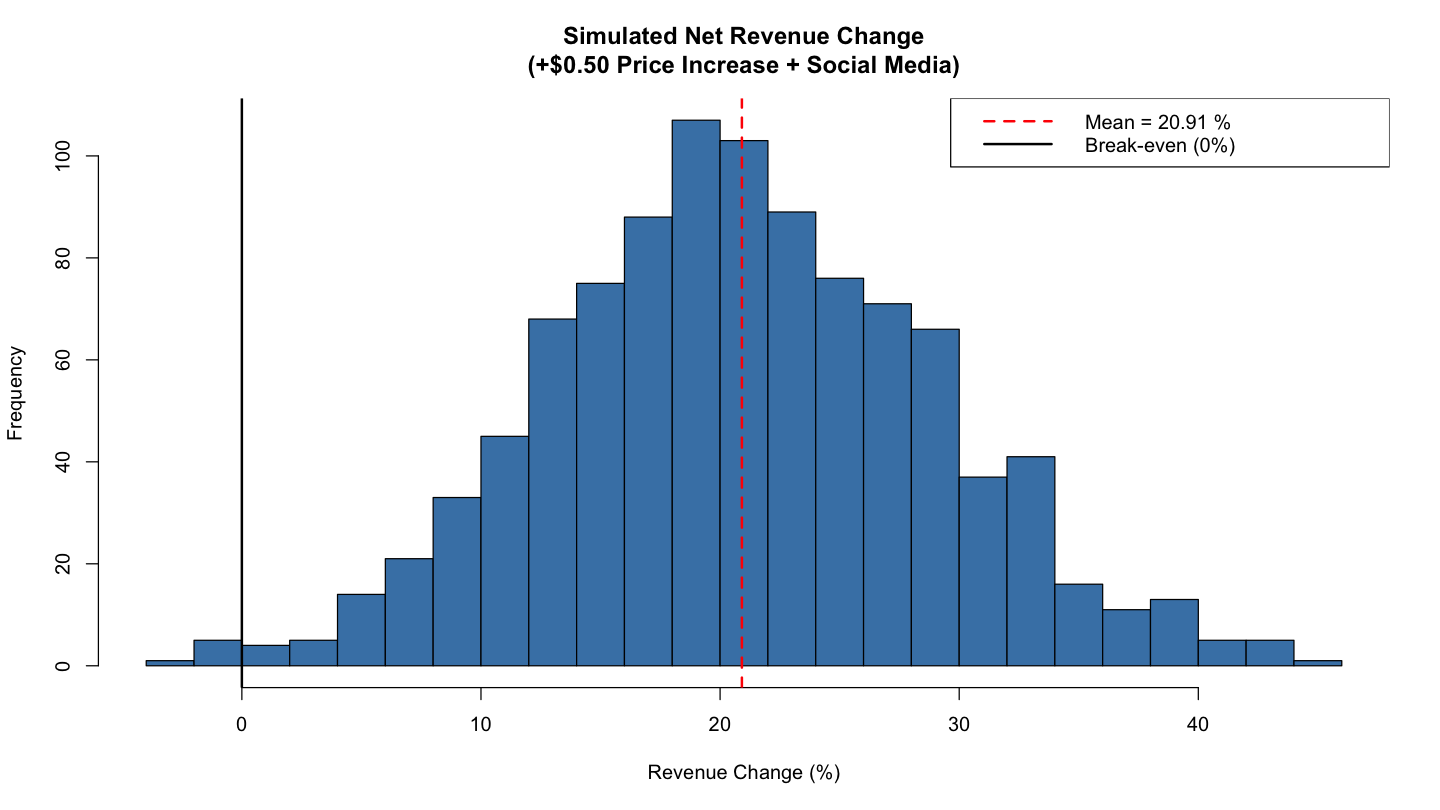

In [470]:
options(repr.plot.width = 12, repr.plot.height = 12 * 9 / 16, repr.plot.res = 120)

par(bg = "white")
hist(net_effect,
     breaks = 30,
     col = "steelblue",
     main = "Simulated Net Revenue Change\n(+$0.50 Price Increase + Social Media)",
     xlab = "Revenue Change (%)",
     ylab = "Frequency")
abline(v = mean(net_effect), col = "red", lwd = 2, lty = 2)
abline(v = 0, col = "black", lwd = 2)
legend("topright",
       legend = c(paste("Mean =", round(mean(net_effect), 2), "%"),
                  "Break-even (0%)"),
       col = c("red", "black"),
       lty = c(2, 1),
       lwd = 2)

# Conclusion: My Decision

## What I've Learned

This investigation started with a simple worry — my revenue is dropping — and led me through a chain of discoveries:

1. **HDB Malay stalls earn the least** among all locations. The revenue distribution is right-skewed, meaning the typical stall does even worse than the average suggests. I also uncovered a **Simpson's Paradox**: overall, higher prices seem to correlate with higher revenue, but within each location, the relationship is **negative** — higher prices actually hurt revenue.
2. **The location gap is statistically significant.** Confidence intervals (Week 7) don't overlap, a one-sample hypothesis test (Weeks 8-9) rejects $H_0$, and regression with dummies (Week 10) quantifies exactly how much CBD and Tourist stalls earn over HDB.
3. **After controlling for all factors** in a multiple regression (Weeks 10-11), the price coefficient confirms: raising prices alone reduces revenue. But the regression also revealed a powerful lever I hadn't considered — **social media presence significantly boosts revenue**, even after controlling for location, price, and everything else.
4. **Monte Carlo simulation** (Week 12) showed that a **combined strategy** — a modest price increase paired with social media investment — yields a **net positive** revenue effect, with a 95% confidence interval to quantify the uncertainty.

## My Recommendation

As a Malay stall owner at an HDB hawker centre, my strategy is clear:

- **Don't just raise prices** — Discoveries 1-3 showed this hurts revenue in isolation.
- **Invest in social media first:** build an Instagram and TikTok presence, post food photos, engage with food bloggers. The regression shows this alone can boost revenue significantly.
- **Then raise prices modestly (+$0.50):** with a social media audience attracting new customers, the revenue boost from social media more than offsets the modest price penalty.
- **The simulation confirms this works** — the combined strategy yields a positive net revenue change, and the 95% confidence interval gives me a range of outcomes I can plan around.

The data does not have all the answers, but it has given me something I did not have before: a **strategy backed by evidence** — not just "raise prices and hope," but a two-pronged approach that uses social media to grow the customer base while improving margins through a modest price adjustment.